## Задание 1

In [1]:
import numpy as np
import pandas as pd


def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.rename(columns={
        'Customer ID': 'customer_id',
        'Payment Method': 'payment_method',
        'Total Price': 'product_total',
        'Add-on Total': 'addons_total',
        'Unit Price': 'unit_price',
        'Quantity': 'quantity',
        'Purchase Date': 'purchase_date',
        'Shipping Type': 'shipping_method',
        'Product Type': 'product_type',
        'Order Status': 'order_status'
    }).copy()

    columns = ['customer_id', 'payment_method', 'product_total', 'addons_total',
               'unit_price', 'quantity', 'purchase_date', 'shipping_method',
               'product_type', 'order_status']
    df = df.reindex(columns=columns)
    numeric = ['customer_id', 'product_total', 'addons_total', 'unit_price', 'quantity']
    df[numeric] = df[numeric].apply(pd.to_numeric, errors='coerce')
    df['purchase_date'] = pd.to_datetime(df['purchase_date'], format='%Y-%m-%d', errors='coerce')

    # Пропуски в дополнениях = 0; в оплате, доставке и типе товара = Unknown.
    df['addons_total'] = df['addons_total'].fillna(0)
    labels = ['payment_method', 'shipping_method', 'product_type', 'order_status']
    df[labels] = df[labels].astype('string').apply(lambda s: s.str.strip()).replace('', pd.NA)
    df[labels] = df[labels].fillna('Unknown')
    df['payment_method'] = df['payment_method'].replace({'Paypal': 'PayPal'})

    # Исключены отмены, неверные даты/ID, пропуски и бесконечности в обязательных числах,
    # неположительные цены/суммы товаров, отрицательные дополнения и неверные количества.
    valid = (
        df['order_status'].eq('Completed')
        & df['purchase_date'].notna()
        & np.isfinite(df[numeric]).all(axis=1)
        & df['customer_id'].ge(0) & df['customer_id'].mod(1).eq(0)
        & df['unit_price'].gt(0) & df['product_total'].gt(0)
        & df['addons_total'].ge(0)
        & df['quantity'].gt(0) & df['quantity'].mod(1).eq(0)
    )
    df = df.loc[valid].copy()
    df['customer_id'] = df['customer_id'].astype('int64')
    df['quantity'] = df['quantity'].astype('int64')
    # Total Price = цена × количество; общие траты дополнительно включают Add-on Total.
    df['total_spent'] = df['product_total'] + df['addons_total']
    return df.reset_index(drop=True)


def customer_table(df: pd.DataFrame) -> pd.DataFrame:
    # При равной частоте выбирается первый метод по лексикографическому порядку.
    result = df.groupby('customer_id', as_index=False).agg(
        preferred_payment=('payment_method', lambda s: s.mode().sort_values().iloc[0]),
        total_spent=('total_spent', 'sum'),
        addons_spent=('addons_total', 'sum'),
        orders_count=('customer_id', 'size')
    )
    result[['total_spent', 'addons_spent']] = result[['total_spent', 'addons_spent']].round(2)
    return result.sort_values(['total_spent', 'customer_id'], ascending=[False, True]).reset_index(drop=True)

In [2]:
raw = pd.read_csv('electronic_devices_sales.csv')
sales = clean(raw)
print(f'Исходных заказов: {len(raw):,}; после очистки: {len(sales):,}; исключено: {len(raw) - len(sales):,}')

pd.set_option('display.float_format', '{:,.2f}'.format)
customers = customer_table(sales)
customers.to_csv('customer_summary.csv', index=False, encoding='utf-8-sig')
customers.head(10)

Исходных заказов: 20,000; после очистки: 13,432; исключено: 6,568


,customer_id,preferred_payment,total_spent,addons_spent,orders_count
0,11476,PayPal,"30,136.35",198.42,4
1,15399,PayPal,"29,390.27",305.39,3
2,13635,Credit Card,"28,481.39",388.11,4
3,16357,Bank Transfer,"27,838.76",352.75,6
4,12294,Bank Transfer,"27,052.70",477.68,4
5,11332,PayPal,"26,965.89",240.24,4
6,2556,Debit Card,"26,329.06",230.66,6
7,13534,Bank Transfer,"26,261.21",367.61,5
8,17236,Credit Card,"25,167.95",481.93,5
9,14436,Credit Card,"25,014.73",102.31,4


## Задание 2

In [3]:
def build_metrics(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    if df.empty:
        return {
            'revenue_by_shipping': pd.DataFrame(columns=['shipping_method', 'revenue']),
            'revenue_by_product': pd.DataFrame(columns=['product_type', 'revenue']),
            'addons_by_month': pd.DataFrame(columns=['month', 'addons_revenue']),
            'addons_by_quarter': pd.DataFrame(columns=['quarter', 'addons_revenue']),
            'cohort_revenue': pd.DataFrame(index=pd.PeriodIndex([], freq='M', name='cohort'), columns=pd.Index(range(4), name='month_number'), dtype=float),
            'cohort_customers': pd.DataFrame(index=pd.PeriodIndex([], freq='M', name='cohort'), columns=pd.Index(range(4), name='month_number'), dtype=float)
        }

    shipping = df.groupby('shipping_method', as_index=False).agg(revenue=('total_spent', 'sum'))
    product = df.groupby('product_type', as_index=False).agg(revenue=('total_spent', 'sum'))
    shipping = shipping.sort_values('revenue', ascending=False).reset_index(drop=True).round(2)
    product = product.sort_values('revenue', ascending=False).reset_index(drop=True).round(2)

    orders = df.assign(month=df['purchase_date'].dt.to_period('M'))
    months = pd.period_range(orders['month'].min(), orders['month'].max(), freq='M', name='month')
    quarters = pd.period_range(orders['month'].min().asfreq('Q'), orders['month'].max().asfreq('Q'), freq='Q', name='quarter')
    # Пропущенные месяцы и кварталы внутри периода наблюдения добавляются с нулём.
    monthly = orders.groupby('month')['addons_total'].sum().reindex(months, fill_value=0)
    quarterly = orders.groupby(orders['purchase_date'].dt.to_period('Q'))['addons_total'].sum().reindex(quarters, fill_value=0)
    monthly = monthly.rename_axis('month').rename('addons_revenue').round(2).reset_index()
    quarterly = quarterly.rename_axis('quarter').rename('addons_revenue').round(2).reset_index()

    orders['cohort'] = orders.groupby('customer_id')['month'].transform('min')
    orders['month_number'] = orders['month'].astype('int64') - orders['cohort'].astype('int64')
    first_four = orders.loc[orders['month_number'].between(0, 3)]
    grouped = first_four.groupby(['cohort', 'month_number']).agg(
        revenue=('total_spent', 'sum'), customers=('customer_id', 'nunique')
    )
    cohorts = pd.PeriodIndex(sorted(orders['cohort'].unique()), freq='M', name='cohort')
    ages = pd.Index(range(4), name='month_number')
    revenue = grouped['revenue'].unstack('month_number').reindex(index=cohorts, columns=ages).fillna(0)
    customers = grouped['customers'].unstack('month_number').reindex(index=cohorts, columns=ages).fillna(0)
    # Нет заказов в наблюдаемом месяце = 0; месяц ещё не наступил в датасете = NaN.
    # Когорта определяется первым завершённым заказом в имеющемся датасете.
    observed = cohorts.asi8[:, None] + np.arange(4) <= orders['month'].max().ordinal
    revenue = revenue.where(observed).round(2)
    customers = customers.where(observed)

    return {
        'revenue_by_shipping': shipping,
        'revenue_by_product': product,
        'addons_by_month': monthly,
        'addons_by_quarter': quarterly,
        'cohort_revenue': revenue,
        'cohort_customers': customers
    }

In [4]:
from IPython.display import display

metrics = build_metrics(sales)
for name, table in metrics.items():
    print(name)
    display(table)

revenue_by_shipping


,shipping_method,revenue
0,Standard,"14,676,351.95"
1,Expedited,"8,610,437.09"
2,Same Day,"8,469,574.60"
3,Overnight,"5,982,983.40"
4,Express,"5,725,863.77"


revenue_by_product


,product_type,revenue
0,Smartphone,"14,630,325.53"
1,Smartwatch,"9,557,416.02"
2,Laptop,"8,536,583.03"
3,Tablet,"7,893,431.51"
4,Headphones,"2,847,454.72"


addons_by_month


...

,quarter,addons_revenue
0,2023Q3,"5,337.61"
1,2023Q4,"73,356.77"
2,2024Q1,"258,222.60"
3,2024Q2,"256,316.84"
4,2024Q3,"242,361.42"


cohort_revenue


month_number,0,1,2,3
cohort,,,,
2023-09,"288,973.36","33,966.24","27,171.95","33,728.93"
2023-10,"1,547,512.83","57,546.84","105,708.66","105,318.56"
2023-11,"1,329,851.04","51,831.74","120,410.29","49,399.43"
2023-12,"1,141,503.77","70,631.39","51,051.53","66,268.75"
2024-01,"4,300,575.58","224,810.52","363,311.35","367,531.56"
2024-02,"3,551,138.51","237,765.99","258,807.13","276,145.83"
2024-03,"3,492,721.17","309,227.62","249,389.13","247,959.27"
2024-04,"3,176,736.50","255,450.10","270,533.88","246,163.28"
2024-05,"3,129,140.50","184,409.51","242,471.91","186,356.86"


cohort_customers


month_number,0,1,2,3
cohort,,,,
2023-09,121.00,11.00,12.00,12.00
2023-10,581.00,27.00,35.00,36.00
2023-11,482.00,21.00,39.00,24.00
2023-12,442.00,27.00,16.00,23.00
2024-01,"1,236.00",72.00,88.00,88.00
2024-02,"1,029.00",65.00,71.00,75.00
2024-03,"1,028.00",77.00,71.00,72.00
2024-04,907.00,76.00,73.00,63.00
2024-05,906.00,53.00,66.00,50.00


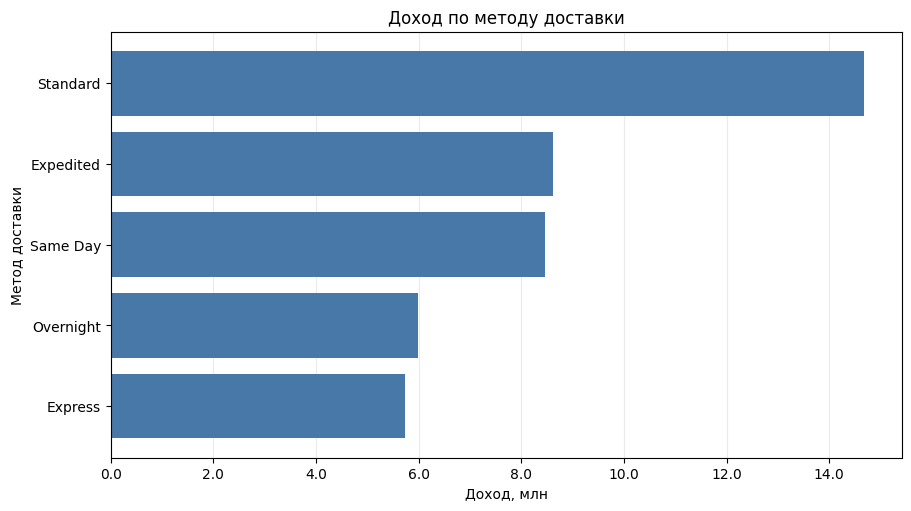

In [5]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

shipping = metrics['revenue_by_shipping'].sort_values('revenue')
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.barh(shipping['shipping_method'], shipping['revenue'], color='#4878A8')
ax.set(title='Доход по методу доставки', xlabel='Доход, млн', ylabel='Метод доставки')
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1_000_000:.1f}'))
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.25)
fig.savefig('revenue_by_shipping.png', dpi=150)
plt.show()

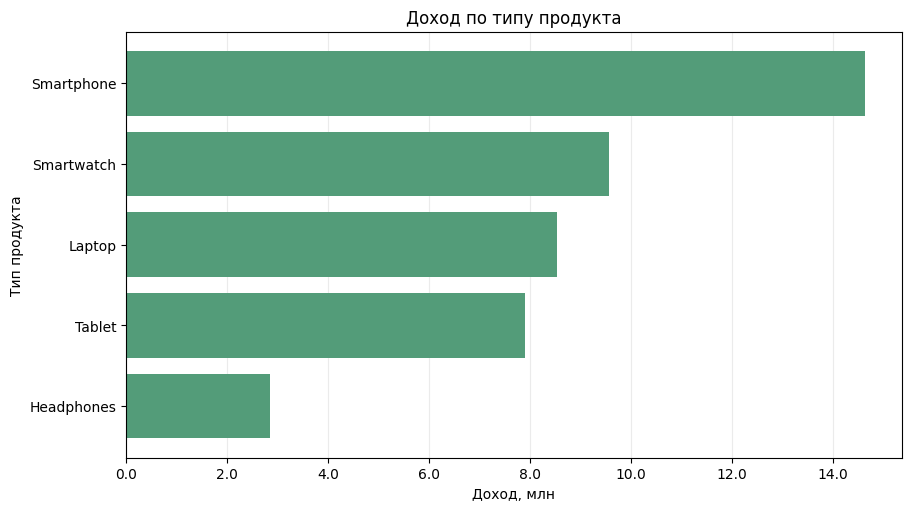

In [6]:
product = metrics['revenue_by_product'].sort_values('revenue')
fig, ax = plt.subplots(figsize=(9, 5), layout='constrained')
ax.barh(product['product_type'], product['revenue'], color='#539C79')
ax.set(title='Доход по типу продукта', xlabel='Доход, млн', ylabel='Тип продукта')
ax.xaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1_000_000:.1f}'))
ax.set_axisbelow(True)
ax.grid(axis='x', alpha=0.25)
fig.savefig('revenue_by_product.png', dpi=150)
plt.show()

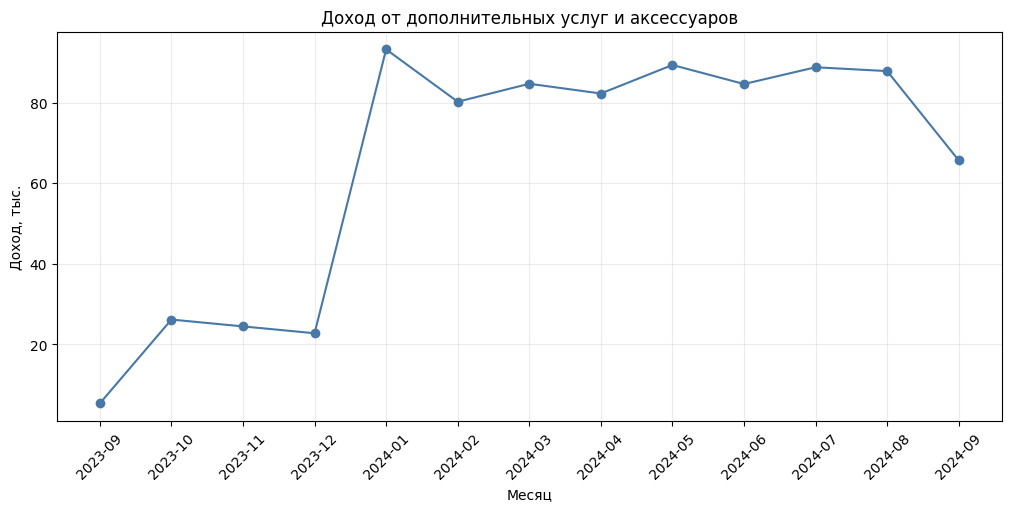

In [7]:
monthly = metrics['addons_by_month']
fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
ax.plot(monthly['month'].astype(str), monthly['addons_revenue'], marker='o', color='#4878A8')
ax.set(title='Доход от дополнительных услуг и аксессуаров', xlabel='Месяц', ylabel='Доход, тыс.')
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, position: f'{value / 1_000:.0f}'))
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.25)
fig.savefig('addons_by_month.png', dpi=150)
plt.show()

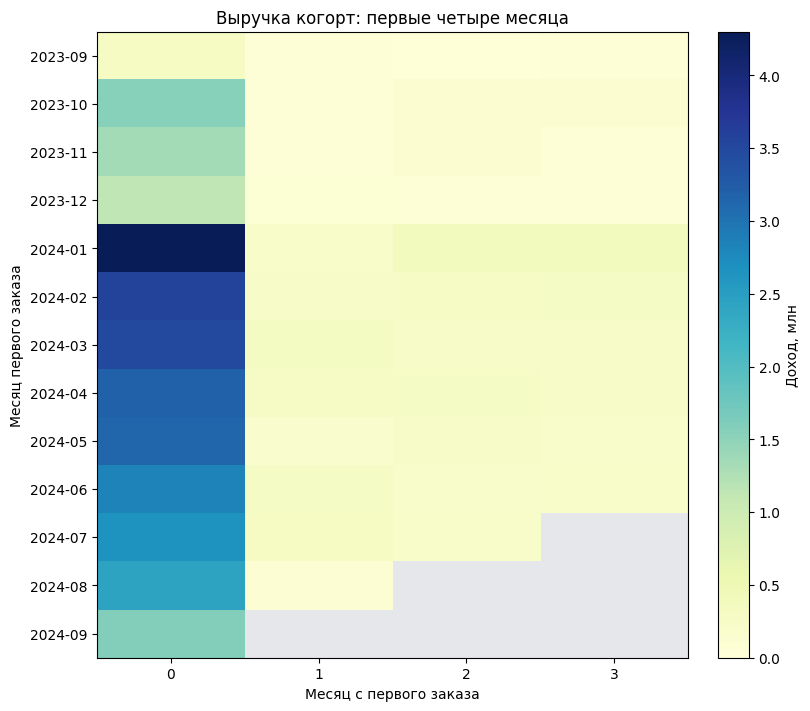

In [8]:
cohort_revenue = metrics['cohort_revenue']
fig, ax = plt.subplots(figsize=(8, 7), layout='constrained')
if cohort_revenue.empty:
    ax.text(0.5, 0.5, 'Нет данных после очистки', ha='center', va='center', transform=ax.transAxes)
else:
    cmap = plt.colormaps['YlGnBu'].copy()
    cmap.set_bad('#e5e7eb')
    image = ax.imshow(cohort_revenue.to_numpy() / 1_000_000, aspect='auto', cmap=cmap, vmin=0)
    ax.set_xticks(range(4), labels=range(4))
    ax.set_yticks(range(len(cohort_revenue)), labels=cohort_revenue.index.astype(str))
    fig.colorbar(image, ax=ax, label='Доход, млн')
ax.set(title='Выручка когорт: первые четыре месяца', xlabel='Месяц с первого заказа', ylabel='Месяц первого заказа')
fig.savefig('cohort_revenue.png', dpi=150)
plt.show()

Наибольший доход приходится на доставку Standard и смартфоны. Доход от дополнений заметно вырос в январе 2024 года. Серые клетки на когортной карте — ещё не наблюдаемые месяцы: их нельзя сравнивать с нулевой выручкой. Первый и последний календарные месяцы в датасете неполные.